In [13]:

import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt


def analytic_signal_hilbert(x: np.ndarray, axis: int = 0) -> np.ndarray:
    """Hilbert analytic signal using only NumPy FFT."""
    n = x.shape[axis]
    h = np.zeros(n, dtype=np.float64)
    if n % 2 == 0:
        h[0] = 1.0
        h[n // 2] = 1.0
        h[1 : n // 2] = 2.0
    else:
        h[0] = 1.0
        h[1 : (n + 1) // 2] = 2.0

    shape = [1] * x.ndim
    shape[axis] = n
    h = h.reshape(shape)
    return np.fft.ifft(np.fft.fft(x, axis=axis) * h, axis=axis)


def das_beamform(
    rf_data: np.ndarray,
    fs: float,
    c: float,
    x_el: np.ndarray,
    x_img: np.ndarray,
    z_img: np.ndarray,
):
    n_samples, _ = rf_data.shape

    xg, zg = np.meshgrid(x_img, z_img)
    img = np.zeros_like(xg, dtype=np.float64)

    for ch, x_i in enumerate(x_el):
        dist = np.sqrt((xg - x_i) ** 2 + zg**2)
        sample_idx = np.rint((2.0 * dist / c) * fs).astype(np.int64)
        np.clip(sample_idx, 0, n_samples - 1, out=sample_idx)
        img += rf_data[:, ch][sample_idx]

    env = np.abs(analytic_signal_hilbert(img, axis=0))
    env /= np.max(env) + np.finfo(np.float64).eps
    env_db = 20.0 * np.log10(env + np.finfo(np.float64).eps)
    return img, env_db, x_el


In [14]:
def load_usb_csv(csv_path: Path) -> np.ndarray:
    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
    if data.ndim == 1:
        data = data[:, np.newaxis]
    return data.astype(np.float64)

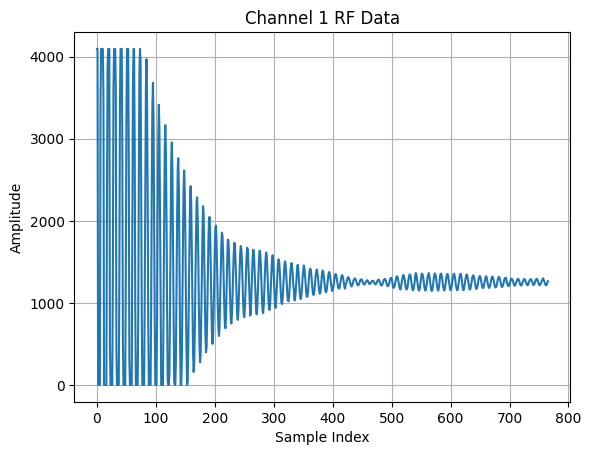

In [15]:
path = Path("data_3-9/test_4.csv")
rf_data = load_usb_csv(path)
fs = 6.25e6
c = 1540.0

ch_1 = rf_data[:, 3]
plt.plot(ch_1)
plt.title("Channel 1 RF Data")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid()

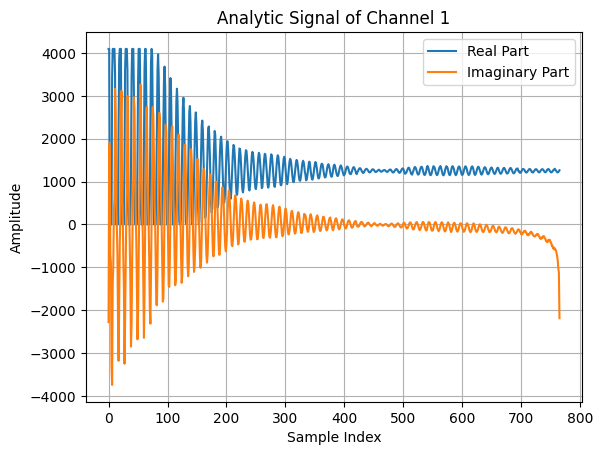

In [16]:
# plot analytic signal
analytic_ch_1 = analytic_signal_hilbert(ch_1)
plt.figure()
plt.plot(np.real(analytic_ch_1), label="Real Part")
plt.plot(np.imag(analytic_ch_1), label="Imaginary Part")
plt.title("Analytic Signal of Channel 1")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

Text(0, 0.5, 'Depth (m)')

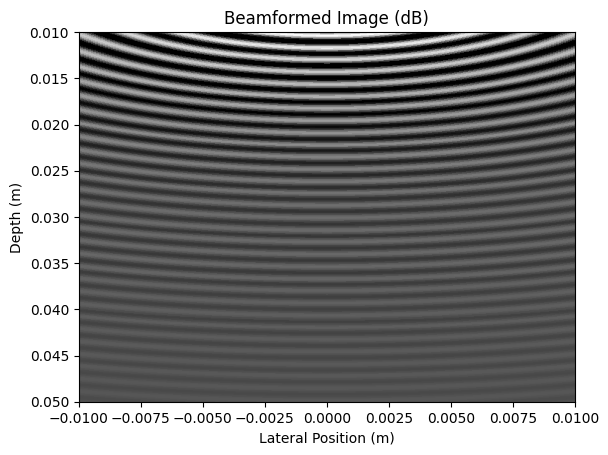

In [25]:
# run beamforming on only channel 1
img, env_db, x_el = das_beamform(
    ch_1[:, np.newaxis],
    fs,
    c,
    x_el=np.array([0.0]),
    x_img=np.linspace(-0.01, 0.01, 500),
    z_img=np.linspace(0.01, 0.05, 500),
)
plt.figure()
plt.imshow(img, extent=[-0.01, 0.01, 0.05, 0.01], aspect="auto", cmap="gray")
plt.title("Beamformed Image (dB)")
plt.xlabel("Lateral Position (m)")
plt.ylabel("Depth (m)") 

In [18]:
def simulate_rf_data(
    n_samples: int,
    fs: float,
    c: float,
    f_c: float,
    pitch: float,
    n_elements: int,
    scatter_x: float,
    scatter_z: float,
    burst_cycles: float,
) -> tuple[np.ndarray, np.ndarray]:
    t = np.arange(n_samples, dtype=np.float64) / fs
    burst_duration = burst_cycles / f_c

    x_el = (np.arange(n_elements) - (n_elements - 1) / 2.0) * pitch
    rf_data = np.zeros((n_samples, n_elements), dtype=np.float64)

    for ch in range(n_elements):
        dist = np.sqrt((scatter_x - x_el[ch]) ** 2 + scatter_z**2)
        t_delay = 2.0 * dist / c
        burst = np.sin(2.0 * np.pi * f_c * (t - t_delay))
        burst *= np.exp(-((t - t_delay) / (burst_duration / 2.5)) ** 2)
        peak = np.max(np.abs(burst))
        if peak > 0:
            burst /= peak
        rf_data[:, ch] = burst

    return t, rf_data

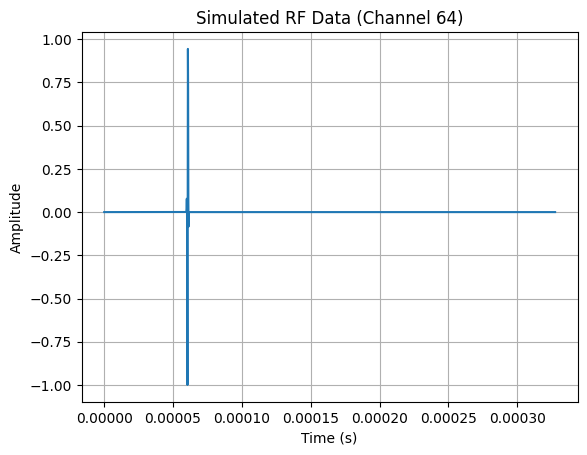

In [19]:
t, rf_data = simulate_rf_data(
    n_samples=2048,
    fs=6.25e6,
    c=1540.0,
    f_c=1e6,
    pitch=3e-3,
    n_elements=16,
    scatter_x=-10e-3,
    scatter_z=45e-3,
    burst_cycles=1.0,
)

plt.figure()
plt.plot(t, rf_data[:, 0])
plt.title("Simulated RF Data (Channel 64)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()

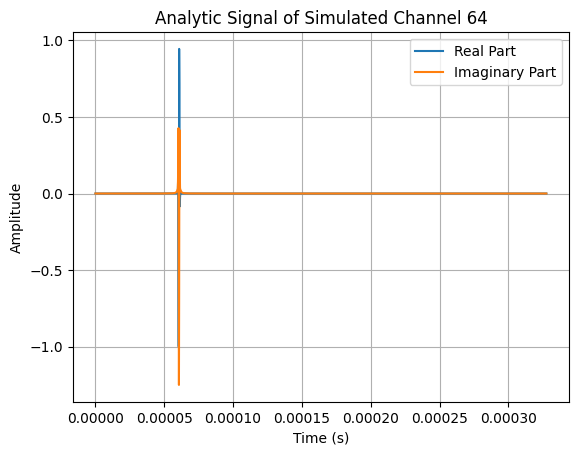

In [23]:
# plot analytic signal of simulated data
analytic_sim_ch_64 = analytic_signal_hilbert(rf_data[:, 0])
plt.figure()
plt.plot(t, np.real(analytic_sim_ch_64), label="Real Part")
plt.plot(t, np.imag(analytic_sim_ch_64), label="Imaginary Part")
plt.title("Analytic Signal of Simulated Channel 64")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

Text(0, 0.5, 'Depth (m)')

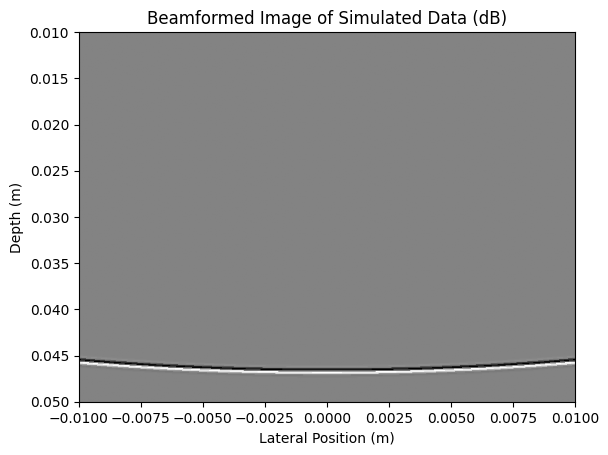

In [26]:
# run DAS beamforming on one channel of simulated data
img, env_db, x_el = das_beamform(
    rf_data[:, 0][:, np.newaxis],
    fs,
    c,
    x_el=np.array([0.0]),
    x_img=np.linspace(-0.01, 0.01, 500),
    z_img=np.linspace(0.01, 0.05, 500),
)
plt.figure()
plt.imshow(img, extent=[-0.01, 0.01, 0.05, 0.01], aspect="auto", cmap="gray")
plt.title("Beamformed Image of Simulated Data (dB)")
plt.xlabel("Lateral Position (m)")
plt.ylabel("Depth (m)")

Text(0, 0.5, 'Depth (m)')

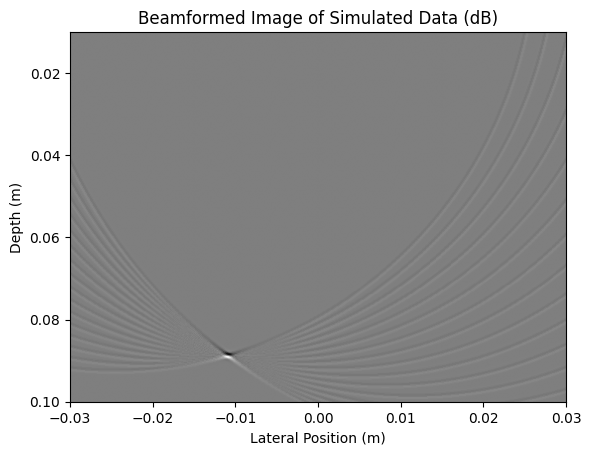

In [29]:
# run DAS beamforming on simulated data

n_samples = 2048
fs = 6.25e6
c = 1540.0
f_c = 1e6
pitch = 3e-3
n_elements = 16
x0 = -10e-3
z0 = 45e-3
burst_cycles = 1.0
x_margin = 5e-3
nx = 500
z_min = 10e-3
z_max = 50e-3
nz = 500


t = np.arange(n_samples, dtype=np.float64) / fs
burst_duration = burst_cycles / f_c
elem_idx = np.arange(n_elements) - (n_elements - 1) / 2.0
x_el = elem_idx * pitch

rf_data = np.zeros((n_samples, n_elements), dtype=np.float64)
for ch in range(n_elements):
    dist = np.sqrt((x0 - x_el[ch]) ** 2 + z0**2)
    t_delay = 2.0 * dist / c
    burst = np.sin(2.0 * np.pi * f_c * (t - t_delay))
    burst *= np.exp(-((t - t_delay) / (burst_duration / 2.5)) ** 2)
    peak = np.max(np.abs(burst))
    if peak > 0:
        burst /= peak
    rf_data[:, ch] = burst

x_img = np.linspace(np.min(x_el) - x_margin, np.max(x_el) + x_margin, nx)
z_img = np.linspace(z_min, z_max, nz)

img, env_db, _ = das_beamform(rf_data, fs=fs, c=c, x_el=x_el, x_img=x_img, z_img=z_img)


plt.figure()
plt.imshow(img, extent=[-0.03, 0.03, 0.1, 0.01], aspect="auto", cmap="gray")
plt.title("Beamformed Image of Simulated Data (dB)")
plt.xlabel("Lateral Position (m)")
plt.ylabel("Depth (m)")